## Packages

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import json
from pathlib import Path
import seaborn as sns
import os
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score


## Data loading

In [3]:
# read in the json files
portfolio = pd.read_json('data/portfolio.json', orient='records', lines=True)
profile = pd.read_json('data/profile.json', orient='records', lines=True)
transcript = pd.read_json('data/transcript.json', orient='records', lines=True)

In [3]:
portfolio.head()

,reward,channels,difficulty,duration,offer_type,id
0,10,"[email, mobile, social]",10,7,bogo,ae264e3637204a6fb9bb56bc8210ddfd
1,10,"[web, email, mobile, social]",10,5,bogo,4d5c57ea9a6940dd891ad53e9dbe8da0
2,0,"[web, email, mobile]",0,4,informational,3f207df678b143eea3cee63160fa8bed
3,5,"[web, email, mobile]",5,7,bogo,9b98b8c7a33c4b65b9aebfe6a799e6d9
4,5,"[web, email]",20,10,discount,0b1e1539f2cc45b7b9fa7c272da2e1d7


In [4]:
profile.head()

,gender,age,id,became_member_on,income
0,None,118,68be06ca386d4c31939f3a4f0e3dd783,20170212,NaN
1,F,55,0610b486422d4921ae7d2bf64640c50b,20170715,112000.0
2,None,118,38fe809add3b4fcf9315a9694bb96ff5,20180712,NaN
3,F,75,78afa995795e4d85b5d9ceeca43f5fef,20170509,100000.0
4,None,118,a03223e636434f42ac4c3df47e8bac43,20170804,NaN


In [5]:
transcript.head()

,person,event,value,time
0,78afa995795e4d85b5d9ceeca43f5fef,offer received,{'offer id': '9b98b8c7a33c4b65b9aebfe6a799e6d9'},0
1,a03223e636434f42ac4c3df47e8bac43,offer received,{'offer id': '0b1e1539f2cc45b7b9fa7c272da2e1d7'},0
2,e2127556f4f64592b11af22de27a7932,offer received,{'offer id': '2906b810c7d4411798c6938adc9daaa5'},0
3,8ec6ce2a7e7949b1bf142def7d0e0586,offer received,{'offer id': 'fafdcd668e3743c1bb461111dcafc2a4'},0
4,68617ca6246f4fbc85e91a2a49552598,offer received,{'offer id': '4d5c57ea9a6940dd891ad53e9dbe8da0'},0


## Data preprocessing

In [4]:
# convert channels column into dummies
channels_d = portfolio['channels'].explode().str.get_dummies().groupby(level=0).sum()
# join new columns to the original df
portfolio = portfolio.join(channels_d).drop(columns='channels')
# change column "id" name to "offer_id"
portfolio.rename(columns={'id':'offer_id'}, inplace=True)

In [7]:
portfolio

,reward,difficulty,duration,offer_type,offer_id,email,mobile,social,web
0,10,10,7,bogo,ae264e3637204a6fb9bb56bc8210ddfd,1,1,1,0
1,10,10,5,bogo,4d5c57ea9a6940dd891ad53e9dbe8da0,1,1,1,1
2,0,0,4,informational,3f207df678b143eea3cee63160fa8bed,1,1,0,1
3,5,5,7,bogo,9b98b8c7a33c4b65b9aebfe6a799e6d9,1,1,0,1
4,5,20,10,discount,0b1e1539f2cc45b7b9fa7c272da2e1d7,1,0,0,1
5,3,7,7,discount,2298d6c36e964ae4a3e7e9706d1fb8c2,1,1,1,1
6,2,10,10,discount,fafdcd668e3743c1bb461111dcafc2a4,1,1,1,1
7,0,0,3,informational,5a8bc65990b245e5a138643cd4eb9837,1,1,1,0
8,5,5,5,bogo,f19421c1d4aa40978ebb69ca19b0e20d,1,1,1,1
9,2,10,7,discount,2906b810c7d4411798c6938adc9daaa5,1,1,0,1


In [5]:
# convert became_member_date to date format
profile['became_member_on'] =  pd.to_datetime(profile['became_member_on'], format='%Y%m%d')
# change the column name id to customer_id
profile.rename(columns={'id':'customer_id'}, inplace=True)

# create a column "valid" to mark valid data
profile['valid'] = profile['age']!=118
# Add dummy columns for gender
gender_dummies = pd.get_dummies(profile['gender'])
# get dummies for gender column
profile = profile.join(gender_dummies).drop(columns='gender')

In [9]:
profile.head()

,age,customer_id,became_member_on,income,valid,F,M,O
0,118,68be06ca386d4c31939f3a4f0e3dd783,2017-02-12,NaN,False,False,False,False
1,55,0610b486422d4921ae7d2bf64640c50b,2017-07-15,112000.0,True,True,False,False
2,118,38fe809add3b4fcf9315a9694bb96ff5,2018-07-12,NaN,False,False,False,False
3,75,78afa995795e4d85b5d9ceeca43f5fef,2017-05-09,100000.0,True,True,False,False
4,118,a03223e636434f42ac4c3df47e8bac43,2017-08-04,NaN,False,False,False,False


In [6]:
# create offer_id column from the value column
offer_id = [list(v.values())[0] if list(v.keys())[0] in['offer id', "offer_id"] else None for v in transcript["value"]]
# create amount column from the value column
amount = [list(v.values())[0] if list(v.keys())[0] == 'amount' else None for v in transcript["value"]]
# add new columns above to the data set
transcript[['offer_id','amount']] = list(zip(offer_id,amount))
# drop value column
transcript.drop(columns=['value'], inplace=True)
# replace " " with "_" for event
transcript['event'] = transcript['event'].str.replace(" ", "_")
# get dummies for "event"
transcript = transcript.join(pd.get_dummies(transcript['event']))
# drop event column
transcript.drop(columns='event', inplace=True)
# change "person" to "customer id"
transcript.rename(columns = {'person':'customer_id'}, inplace=True)


In [11]:
transcript

,customer_id,time,offer_id,amount,offer_completed,offer_received,offer_viewed,transaction
0,78afa995795e4d85b5d9ceeca43f5fef,0,9b98b8c7a33c4b65b9aebfe6a799e6d9,NaN,False,True,False,False
1,a03223e636434f42ac4c3df47e8bac43,0,0b1e1539f2cc45b7b9fa7c272da2e1d7,NaN,False,True,False,False
2,e2127556f4f64592b11af22de27a7932,0,2906b810c7d4411798c6938adc9daaa5,NaN,False,True,False,False
3,8ec6ce2a7e7949b1bf142def7d0e0586,0,fafdcd668e3743c1bb461111dcafc2a4,NaN,False,True,False,False
4,68617ca6246f4fbc85e91a2a49552598,0,4d5c57ea9a6940dd891ad53e9dbe8da0,NaN,False,True,False,False
...,...,...,...,...,...,...,...,...
306529,b3a1272bc9904337b331bf348c3e8c17,714,None,1.59,False,False,False,True
306530,68213b08d99a4ae1b0dcb72aebd9aa35,714,None,9.53,False,False,False,True
306531,a00058cf10334a308c68e7631c529907,714,None,3.61,False,False,False,True
306532,76ddbd6576844afe811f1a3c0fbb5bec,714,None,3.53,False,False,False,True


In [7]:
# join three cleaned data sets together
df_merged = transcript.merge(profile, on = 'customer_id', how='left').merge(portfolio, on='offer_id', how='left')

In [8]:
# change the offer_id to simple format
offer_id_map = {'ae264e3637204a6fb9bb56bc8210ddfd': 'B1',
            '4d5c57ea9a6940dd891ad53e9dbe8da0': 'B2',
            '9b98b8c7a33c4b65b9aebfe6a799e6d9': 'B3',
            'f19421c1d4aa40978ebb69ca19b0e20d': 'B4',
            '0b1e1539f2cc45b7b9fa7c272da2e1d7': 'D1',
            '2298d6c36e964ae4a3e7e9706d1fb8c2': 'D2',
            'fafdcd668e3743c1bb461111dcafc2a4': 'D3',
            '2906b810c7d4411798c6938adc9daaa5': 'D4',
            '3f207df678b143eea3cee63160fa8bed': 'I1',
            '5a8bc65990b245e5a138643cd4eb9837': 'I2'}
df_merged['offer_id'] = df_merged['offer_id'].map(offer_id_map)


In [9]:
# remove invalid records
df_merged = df_merged.loc[df_merged['valid']==True]

In [10]:
df_merged.to_csv('data/df_merged.csv', index=False)

In [289]:
df_merged.loc[df_merged['customer_id']=='78afa995795e4d85b5d9ceeca43f5fef'].sort_values(
  by = ['offer_id','time']
)

,customer_id,time,offer_id,amount,offer_completed,offer_received,offer_viewed,transaction,age,became_member_on,...,duration,offer_type,email,mobile,social,web,age_group,income_group,membership_length,membership_length_group
150598,78afa995795e4d85b5d9ceeca43f5fef,408,B1,NaN,False,True,False,False,75,2017-05-09,...,7.0,bogo,1.0,1.0,1.0,0.0,65+,100k+,602,1-2 yr
163375,78afa995795e4d85b5d9ceeca43f5fef,408,B1,NaN,False,False,True,False,75,2017-05-09,...,7.0,bogo,1.0,1.0,1.0,0.0,65+,100k+,602,1-2 yr
218394,78afa995795e4d85b5d9ceeca43f5fef,510,B1,NaN,True,False,False,False,75,2017-05-09,...,7.0,bogo,1.0,1.0,1.0,0.0,65+,100k+,602,1-2 yr
0,78afa995795e4d85b5d9ceeca43f5fef,0,B3,NaN,False,True,False,False,75,2017-05-09,...,7.0,bogo,1.0,1.0,0.0,1.0,65+,100k+,602,1-2 yr
15561,78afa995795e4d85b5d9ceeca43f5fef,6,B3,NaN,False,False,True,False,75,2017-05-09,...,7.0,bogo,1.0,1.0,0.0,1.0,65+,100k+,602,1-2 yr
47583,78afa995795e4d85b5d9ceeca43f5fef,132,B3,NaN,True,False,False,False,75,2017-05-09,...,7.0,bogo,1.0,1.0,0.0,1.0,65+,100k+,602,1-2 yr
201572,78afa995795e4d85b5d9ceeca43f5fef,504,B4,NaN,False,True,False,False,75,2017-05-09,...,5.0,bogo,1.0,1.0,1.0,1.0,65+,100k+,602,1-2 yr
218395,78afa995795e4d85b5d9ceeca43f5fef,510,B4,NaN,True,False,False,False,75,2017-05-09,...,5.0,bogo,1.0,1.0,1.0,1.0,65+,100k+,602,1-2 yr
262138,78afa995795e4d85b5d9ceeca43f5fef,582,B4,NaN,False,False,True,False,75,2017-05-09,...,5.0,bogo,1.0,1.0,1.0,1.0,65+,100k+,602,1-2 yr
53176,78afa995795e4d85b5d9ceeca43f5fef,168,I2,NaN,False,True,False,False,75,2017-05-09,...,3.0,informational,1.0,1.0,1.0,0.0,65+,100k+,602,1-2 yr


## EDA

### EDA automated report

In [22]:
# import sweetviz as automated EDA report
import sweetviz as sv
# generate sweetiz eda report
sv_eda_report = sv.analyze(df_merged)
# display report
sv_eda_report.show_html("sweetviz_report.html")

                                             |          | [  0%]   00:00 -> (? left)

Report sweetviz_report.html was generated! NOTEBOOK/COLAB USERS: the web browser MAY not pop up, regardless, the report IS saved in your notebook/colab files.


In [262]:
from pandas_profiling import ProfileReport
# generate pandas eda profile report
pd_eda_report = ProfileReport(df_merged)
# save report to hmtl
pd_eda_report.to_file("Pandas Profile Report.html")

/var/folders/cr/df6gvtx90rz5bg2m0clb1gym0000gn/T/ipykernel_17675/1831893333.py:1: DeprecationWarning: `import pandas_profiling` is going to be deprecated by April 1st. Please use `import ydata_profiling` instead.
  from pandas_profiling import ProfileReport


Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

100%|██████████| 26/26 [00:01<00:00, 21.76it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

### Offers metrics distributions

Customer demographics

In [13]:
df_merged['membership_length'].min()

159

In [9]:
# age groups
bins = [0,25,35,45,55,65,float('inf')]
labels = ['<25','25-35','35-45','45-55','55-65','65+']
df_merged['age_group'] = pd.cut(
  df_merged['age'],
  bins=bins,
  labels=labels,
  right=False
)

# income groups
bins = [0, 50000, 80000, 100000, float('inf') ]
labels = ['<50k', '50k-80k', '80-100k','100k+']
df_merged['income_group'] = pd.cut(
  df_merged['income'],
  bins = bins,
  labels = labels,
  right=False
)

# membership length
df_merged['membership_length'] = (pd.Timestamp('2019-01-01') - pd.to_datetime(df_merged['became_member_on'], format='%Y%m%d')).dt.days
bins = [0, 187, 364, 728, 1820, float('inf')]
labels = ['<0.5 yr', '0.5-1 yr', '1-2 yr',' 2-5 yr', '5+ yr']
df_merged['membership_length_group'] = pd.cut(
  df_merged['membership_length'],
  bins = bins,
  labels = labels,
  right=False
)

Distributions by offer type

In [10]:

df_merged.loc[df_merged['customer_id']=='78afa995795e4d85b5d9ceeca43f5fef']

,customer_id,time,offer_id,amount,offer_completed,offer_received,offer_viewed,transaction,age,became_member_on,...,duration,offer_type,email,mobile,social,web,age_group,income_group,membership_length,membership_length_group
0,78afa995795e4d85b5d9ceeca43f5fef,0,B3,NaN,False,True,False,False,75,2017-05-09,...,7.0,bogo,1.0,1.0,0.0,1.0,65+,100k+,602,<50k
15561,78afa995795e4d85b5d9ceeca43f5fef,6,B3,NaN,False,False,True,False,75,2017-05-09,...,7.0,bogo,1.0,1.0,0.0,1.0,65+,100k+,602,<50k
47582,78afa995795e4d85b5d9ceeca43f5fef,132,NaN,19.89,False,False,False,True,75,2017-05-09,...,NaN,NaN,NaN,NaN,NaN,NaN,65+,100k+,602,<50k
47583,78afa995795e4d85b5d9ceeca43f5fef,132,B3,NaN,True,False,False,False,75,2017-05-09,...,7.0,bogo,1.0,1.0,0.0,1.0,65+,100k+,602,<50k
49502,78afa995795e4d85b5d9ceeca43f5fef,144,NaN,17.78,False,False,False,True,75,2017-05-09,...,NaN,NaN,NaN,NaN,NaN,NaN,65+,100k+,602,<50k
53176,78afa995795e4d85b5d9ceeca43f5fef,168,I2,NaN,False,True,False,False,75,2017-05-09,...,3.0,informational,1.0,1.0,1.0,0.0,65+,100k+,602,<50k
85291,78afa995795e4d85b5d9ceeca43f5fef,216,I2,NaN,False,False,True,False,75,2017-05-09,...,3.0,informational,1.0,1.0,1.0,0.0,65+,100k+,602,<50k
87134,78afa995795e4d85b5d9ceeca43f5fef,222,NaN,19.67,False,False,False,True,75,2017-05-09,...,NaN,NaN,NaN,NaN,NaN,NaN,65+,100k+,602,<50k
92104,78afa995795e4d85b5d9ceeca43f5fef,240,NaN,29.72,False,False,False,True,75,2017-05-09,...,NaN,NaN,NaN,NaN,NaN,NaN,65+,100k+,602,<50k
141566,78afa995795e4d85b5d9ceeca43f5fef,378,NaN,23.93,False,False,False,True,75,2017-05-09,...,NaN,NaN,NaN,NaN,NaN,NaN,65+,100k+,602,<50k


In [166]:
# offer type vs. total offer status
offer_type_df1 = df_merged[
  ['customer_id','offer_completed','offer_received','offer_viewed','offer_type','age_group','income_group']
  ].groupby(
  by = ['offer_type','age_group','income_group']
).agg(
 sum_receives = ('offer_received','sum'),
 sum_views = ('offer_viewed','sum'),
 sum_completes = ('offer_completed','sum')
).reset_index()


/var/folders/cr/df6gvtx90rz5bg2m0clb1gym0000gn/T/ipykernel_17675/451293974.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  ].groupby(


In [167]:
offer_type_df1

,offer_type,age_group,income_group,sum_receives,sum_views,sum_completes
0,bogo,<25,<50k,826,671,304
1,bogo,<25,50k-80k,752,603,340
2,bogo,<25,80-100k,0,0,0
3,bogo,<25,100k+,0,0,0
4,bogo,25-35,<50k,1142,917,468
...,...,...,...,...,...,...
67,informational,55-65,100k+,315,183,0
68,informational,65+,<50k,697,446,0
69,informational,65+,50k-80k,1848,1370,0
70,informational,65+,80-100k,908,650,0


In [253]:
# create image folder
folder_path = 'images'
if os.path.exists(folder_path):
  print('folder already exists')
else:
  os.makedirs(folder_path, exist_ok=False)
  print('folder created')

folder created


In [254]:
# create image subfolders
folder_path = 'images/eda'
if os.path.exists(folder_path):
  print('folder already exists')
else:
  os.makedirs(folder_path, exist_ok=False)
  print('folder created')

folder created


Visualize the offer type distributions

/var/folders/cr/df6gvtx90rz5bg2m0clb1gym0000gn/T/ipykernel_17675/260829057.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  plot_df = offer_type_df1[offer_type_df1['offer_type']==offer_type].groupby(
/var/folders/cr/df6gvtx90rz5bg2m0clb1gym0000gn/T/ipykernel_17675/260829057.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  plot_df = offer_type_df1[offer_type_df1['offer_type']==offer_type].groupby(
/var/folders/cr/df6gvtx90rz5bg2m0clb1gym0000gn/T/ipykernel_17675/260829057.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observ

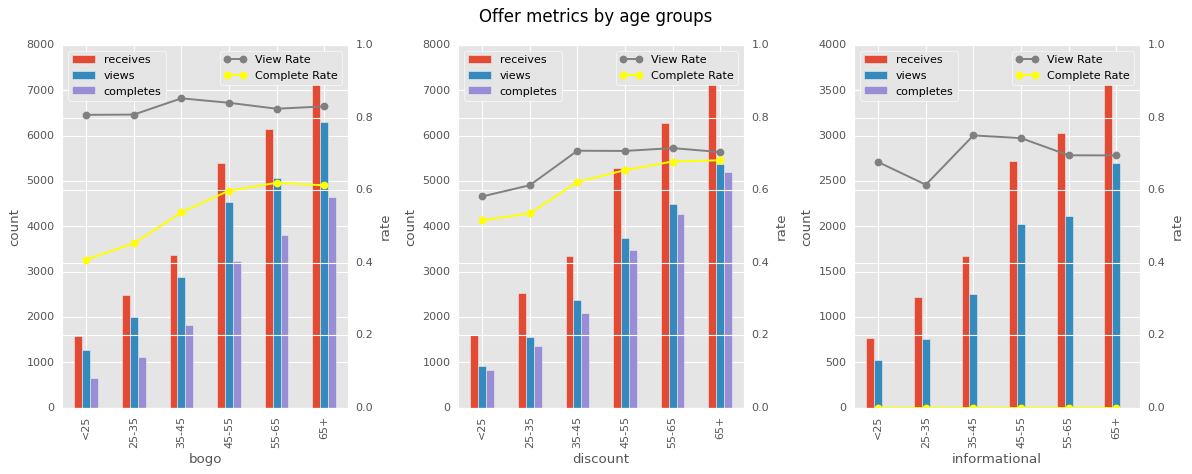

In [269]:
# offer type vs. offer metrics by ages

plt.style.use('ggplot')
fig, axes = plt.subplots(1,3, figsize=(15,6))
for ax, offer_type in zip(axes, ['bogo','discount','informational']):
  plot_df = offer_type_df1[offer_type_df1['offer_type']==offer_type].groupby(
  by = 'age_group'
).agg(
  receives = ('sum_receives','sum'),
  views = ('sum_views', 'sum'),
  completes = ('sum_completes','sum')
)
  plot_df['view_rate'] = plot_df['views']/plot_df['receives']
  plot_df['complete_rate'] = plot_df['completes']/plot_df['receives']
  plot_df[['receives','views','completes']].plot(
    kind ='bar',
    ax=ax
  )
  ax.set_xlabel(offer_type)
  ax.set_ylabel('count')

  ax2 = ax.twinx()
  ax2.plot(
    range(len(plot_df)),
    plot_df['view_rate'],
    marker='o',
    label='View Rate',
    color='gray'
)
  ax2.plot(
      range(len(plot_df)),
      plot_df['complete_rate'],
      marker='o',
      label='Complete Rate',
      color='yellow'
  )
  ax2.set_ylabel('rate')
  ax2.set_ylim(0, 1)
  ax2.legend(loc='upper right')
fig.suptitle('Offer metrics by age groups', fontsize=15)
plt.tight_layout()
plt.savefig('images/eda/offer_metrics_by_age.png')

Discount offers show higher complete rate than Bogo offers across all ages, but more significant among the younger (<35 yr old) customers.

In [154]:
offer_type_df1

,offer_type,age_group,income_group,sum_receives,sum_views,sum_completes
0,bogo,<25,<10k,0,0,0
1,bogo,<25,10k-50k,826,671,304
2,bogo,<25,50-100k,752,603,340
3,bogo,<25,100k+,0,0,0
4,bogo,25-35,<10k,0,0,0
...,...,...,...,...,...,...
67,informational,55-65,100k+,315,183,0
68,informational,65+,<10k,0,0,0
69,informational,65+,10k-50k,697,446,0
70,informational,65+,50-100k,2756,2020,0


/var/folders/cr/df6gvtx90rz5bg2m0clb1gym0000gn/T/ipykernel_17675/1493261896.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  plot_data = offer_type_df1.loc[offer_type_df1['offer_type']==offer_type].groupby(
/var/folders/cr/df6gvtx90rz5bg2m0clb1gym0000gn/T/ipykernel_17675/1493261896.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  plot_data = offer_type_df1.loc[offer_type_df1['offer_type']==offer_type].groupby(
/var/folders/cr/df6gvtx90rz5bg2m0clb1gym0000gn/T/ipykernel_17675/1493261896.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pand

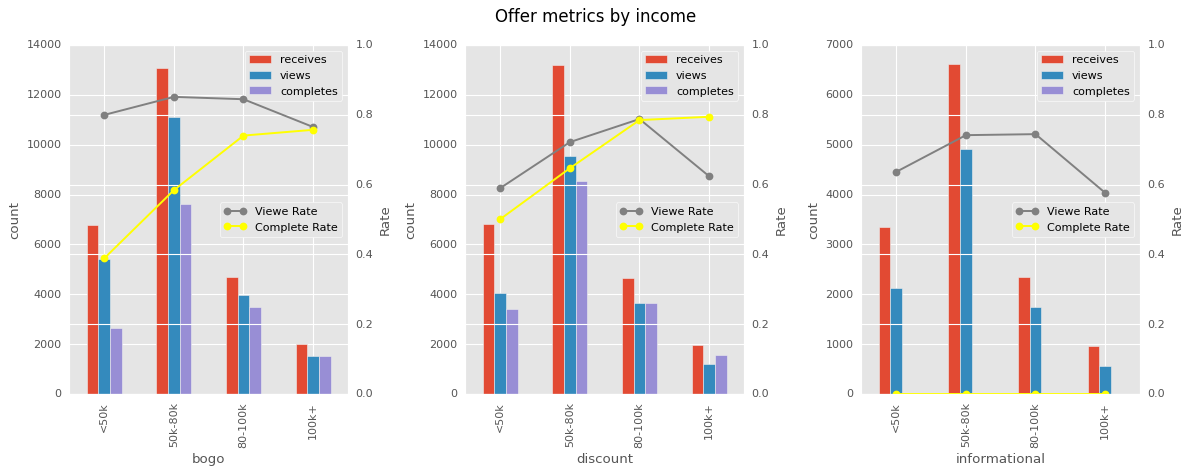

In [270]:
# offer type vs. offer metrics by income
plt.style.use('ggplot')
fig, axes = plt.subplots(1, 3, figsize = (15,6))
for ax, offer_type in zip(axes, ['bogo','discount','informational']):
  plot_data = offer_type_df1.loc[offer_type_df1['offer_type']==offer_type].groupby(
    'income_group'
  ).agg(
    receives = ('sum_receives','sum'),
    views = ('sum_views','sum'),
    completes = ('sum_completes','sum'),
  )
  plot_data['view_rate'] = plot_data['views']/plot_data['receives']
  plot_data['complete_rate'] = plot_data['completes']/plot_data['receives']
  plot_data[['receives','views','completes']].plot(
    kind = 'bar',
    ax = ax
  )
  ax.set_xlabel(offer_type)
  ax.set_ylabel('count')

  ax2 = ax.twinx()
  ax2.plot(
    range(len(plot_data)),
    plot_data['view_rate'],
    marker='o',
    label='Viewe Rate',
    color='gray'
  )
  ax2.plot(
    range(len(plot_data)),
    plot_data['complete_rate'],
    marker='o',
    label='Complete Rate',
    color='yellow'
  )
  ax2.set_ylabel('Rate')
  ax2.set_ylim(0,1)
  ax2.legend(loc='right')

fig.suptitle('Offer metrics by income', fontsize=15)
fig.tight_layout()
plt.savefig('images/eda/offer_metrics_by_income.png')


Discount offers have higher completed offers among lower income (<80k) customers, but similar among higher income customers.

In [177]:
# offer type vs. offer status by membership length

offer_type_df3 = df_merged[['offer_type','membership_length','membership_length_group','offer_received','offer_viewed','offer_completed']].groupby(
  by = ['offer_type','membership_length']
).agg(
  receives = ('offer_received','sum'),
  views = ('offer_viewed','sum'),
  completes = ('offer_completed','sum')
).reset_index()

# # create membership length bins
# bins = [0,  182, 365, 728, 1095, 1460, 1825, float('inf')]
# labels = ['<0.5 yr', '0.5-1 yr', '1-2 yr',' 2-3 yr', '3-4 yr', '4-5 yr','5+ yr']
# offer_type_df3['membership_length_group'] = pd.cut(
#   offer_type_df3['membership_length'],
#   bins = bins,
#   labels = labels,
#   right=False
# )

/var/folders/cr/df6gvtx90rz5bg2m0clb1gym0000gn/T/ipykernel_17675/1522873505.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  plot_data = offer_type_df3[offer_type_df3['offer_type']==offer_type].groupby(
/var/folders/cr/df6gvtx90rz5bg2m0clb1gym0000gn/T/ipykernel_17675/1522873505.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  plot_data = offer_type_df3[offer_type_df3['offer_type']==offer_type].groupby(
/var/folders/cr/df6gvtx90rz5bg2m0clb1gym0000gn/T/ipykernel_17675/1522873505.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass

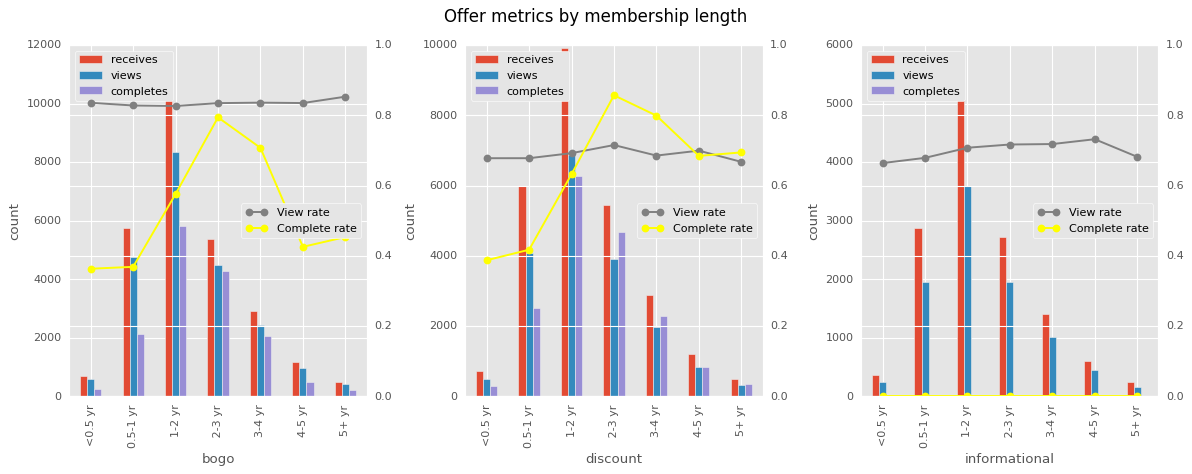

In [271]:
# plot offer metrics by offer type and membership
plt.style.use('ggplot')
fig, axes = plt.subplots(1, 3, figsize = (15,6))
for ax, offer_type in zip(axes, ['bogo','discount','informational']):
  plot_data = offer_type_df3[offer_type_df3['offer_type']==offer_type].groupby(
    by = 'membership_length_group'
  ).agg(
    receives = ('receives','sum'),
    views = ('views','sum'),
    completes = ('completes','sum')
  )
  plot_data['view_rate'] = plot_data['views']/ plot_data['receives']
  plot_data['complete_rate'] = plot_data['completes']/ plot_data['receives']
  plot_data[['receives','views','completes']].plot(
    kind='bar',
    ax = ax
  )
  ax.set_ylabel('count')
  ax.set_xlabel(offer_type)
  ax.legend(loc = 'upper left')

  ax2 = ax.twinx()
  ax2.plot(
    range(len(plot_data)),
    plot_data['view_rate'],
    marker='o',
    label='View rate',
    color='gray'
  )
  ax2.plot(
    range(len(plot_data)),
    plot_data['complete_rate'],
    marker='o',
    label='Complete rate',
    color='yellow'
  )
  ax2.legend(loc='right')
  ax2.set_ylim(0,1)
plt.suptitle('Offer metrics by membership length', fontsize=15)
fig.tight_layout()
plt.savefig('images/eda/offer_metrics_by_membership_length.png')

Both offers have similar and high complete rate for 1-4 years of members. Both are low for <1 year old members. Discount offers have higher complete rate for >4 year (longer term) loyalty members.

In [222]:
# offer type vs. offer status by distribution channel
offer_type_df4 = pd.DataFrame()
for p in ['mobile','email','social','web']:
  df = df_merged.loc[df_merged[p]==1,['offer_type','offer_received','offer_viewed','offer_completed']]
  df['platform'] = p
  offer_type_df4 = pd.concat([offer_type_df4, df])

In [230]:
offer_type_df4

,offer_type,offer_received,offer_viewed,offer_completed,platform
0,bogo,True,False,False,mobile
2,discount,True,False,False,mobile
5,bogo,True,False,False,mobile
7,informational,True,False,False,mobile
12,bogo,True,False,False,mobile
...,...,...,...,...,...
306475,discount,False,False,True,web
306490,informational,False,True,False,web
306507,discount,False,True,False,web
306509,discount,False,False,True,web


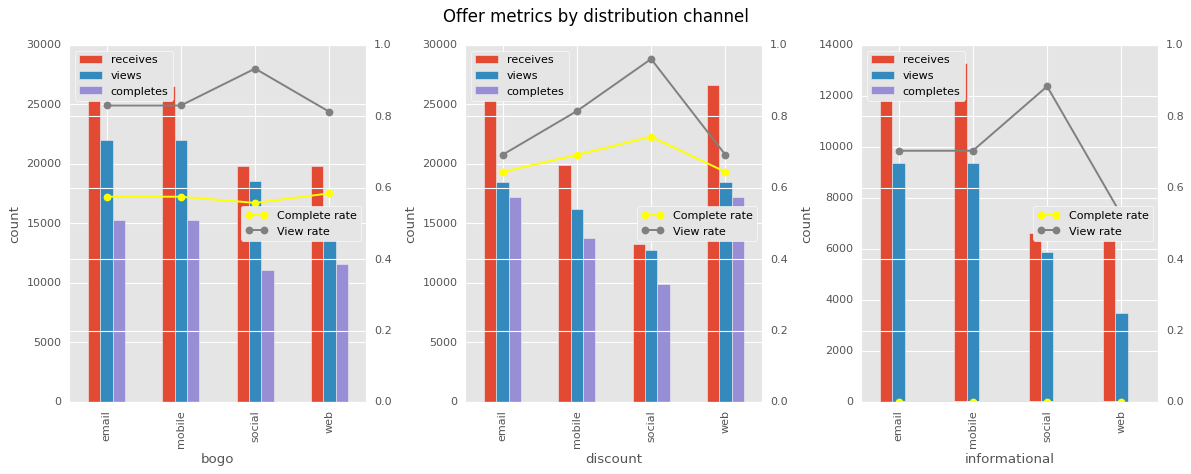

In [274]:
plt.style.use('ggplot')

fig, axes = plt.subplots(1, 3, figsize = (15,6))
for ax, offer_type in zip(axes, ['bogo','discount','informational']):
  plot_df = offer_type_df4.loc[offer_type_df4['offer_type']==offer_type].groupby(
    by = 'platform'
  ).agg(
    receives = ('offer_received','sum'),
    views = ('offer_viewed','sum'),
    completes = ('offer_completed','sum')
  )
  plot_df['view_rate'] = plot_df['views']/ plot_df['receives']
  plot_df['complete_rate'] = plot_df['completes']/ plot_df['receives']
  plot_df[['receives','views','completes']].plot(
    kind='bar',
    ax = ax
  )
  ax.set_xlabel(offer_type)
  ax.set_ylabel('count')
  ax.legend(loc='upper left')

  ax2 = ax.twinx()
  ax2.plot(
    range(len(plot_df)),
    plot_df['complete_rate'],
    marker='o',
    label='Complete rate',
    color='yellow'
  )
  ax2.plot(
    range(len(plot_df)),
    plot_df['view_rate'],
    marker='o',
    label='View rate',
    color='gray'
  )
  ax2.legend(loc='right')
  ax2.set_ylim(0,1)
plt.suptitle('Offer metrics by distribution channel', fontsize=15)
plt.tight_layout()
plt.savefig('images/eda/offer_metrics_by_distribution_channel.png')

Disount offers perform better overall than Bogo on all channels; significantly better than Bogo on the social media and model channels. 

In [295]:
# create a column for offer type category
offer_type_category = df_merged[['difficulty','reward','duration','offer_type']].astype(str).agg('_'.join, axis=1)
df_merged['offer_type_category']=offer_type_category


In [315]:
# offer metrics by offer type category

offer_type_df5 = df_merged.loc[
  (df_merged['offer_type'].isna()==False) & (df_merged['offer_type']!='informational'),['offer_type_category','offer_received','offer_viewed','offer_completed']
                               ].groupby(
  by = ['offer_type_category']
).agg(
  receives = ('offer_received','sum'),
  views = ('offer_viewed','sum'),
  completes = ('offer_completed','sum')
).reset_index()

offer_type_df5['view_rate'] = offer_type_df5['views']/ offer_type_df5['receives']
offer_type_df5['complete_rate'] = offer_type_df5['completes']/ offer_type_df5['receives']

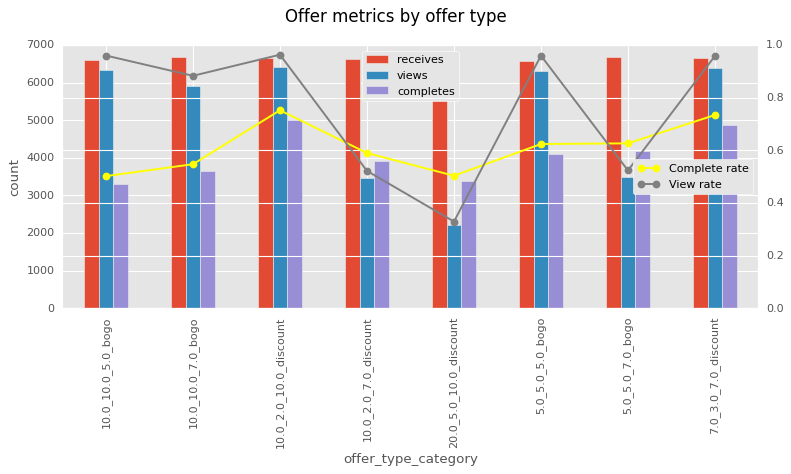

In [327]:
plt.style.use('ggplot')
fig, ax = plt.subplots(figsize=(10,6))
ax = offer_type_df5[['receives','views','completes','offer_type_category']].plot(
  x = 'offer_type_category',
  y = ['receives','views','completes'],
  kind='bar',
  ax = ax
  )
ax.set_xlabel('offer_type_category')
ax.set_ylabel('count')
plt.suptitle('Offer metrics by offer type', fontsize='15')

ax2 = ax.twinx()
ax2.plot(
  range(len(offer_type_df5)),
 offer_type_df5['complete_rate'],
  marker='o',
  label='Complete rate',
  color='yellow'
)
ax2.plot(
  range(len(offer_type_df5)),
  offer_type_df5['view_rate'],
  marker='o',
  label='View rate',
  color='gray'
)
ax2.legend(loc='right')
ax2.set_ylim(0,1)
fig.tight_layout()
plt.savefig('images/eda/offer_metrics_by_offer_types.png')

Discount offer with $10 min-spend, $2 discount lasting 10 days has the highest view and complete rates. The second highest complete rate offer is $7 min-spend, $3 discount lasting for 7 days. The Discount offer with $20 min spend apparently has the lowest views and completed offers.

### EDA sumary
Offer views and complete rates are different by offer type category, with Discount offers performing better thand BOGO offers. The performance of Discount offers is different by ages, membership length, distribution channels and income levels.  

### Correlations

In [389]:
# creat a df for the correlation analysis with selective variables
cor_df = df_merged.loc[
  (df_merged['offer_type'].isna()==False) & (df_merged['offer_type']!='informational'),
  ['customer_id','offer_type_category','income','age','membership_length','offer_completed','offer_received','mobile','email','social','web']
  ]

# convert offer type as dummy variables
offer_type_dummiees = pd.get_dummies(cor_df['offer_type_category']).astype(float)
cor_df = cor_df.join(offer_type_dummies)

In [390]:
cor_df = cor_df.groupby(
  by = ['offer_type_category','customer_id','income','age','membership_length','mobile','email','social','web',
       '10.0_10.0_5.0_bogo',	'10.0_10.0_7.0_bogo','10.0_2.0_10.0_discount',	'10.0_2.0_7.0_discount',	'20.0_5.0_10.0_discount',
       '5.0_5.0_5.0_bogo',	'5.0_5.0_7.0_bogo',	'7.0_3.0_7.0_discount'
      ]
).agg(
  receives = ('offer_received','sum'),
  completes = ('offer_completed','sum'),
).reset_index()

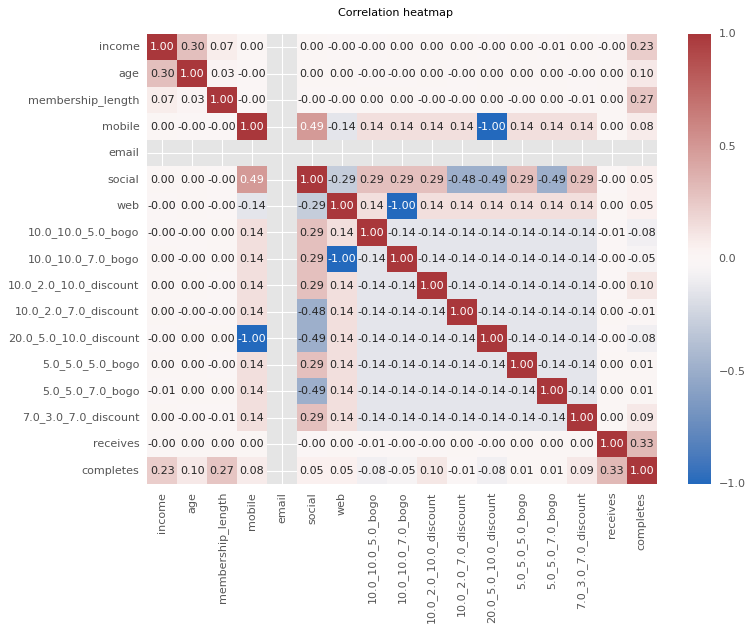

In [406]:
# create correlation heatmap
fig, ax = plt.subplots(figsize=(10,8))
cor = cor_df.drop(columns=['customer_id','offer_type_category']).corr(method='spearman')
sns.heatmap(cor,
            annot=True,
            cmap='vlag',
            fmt='.2f',
            ax=ax
            )
plt.suptitle('Correlation heatmap')
plt.tight_layout()
plt.savefig('images/eda/correlation_heatmap.png')
plt.show()

### Correlation conclusion
The heatmap shows that age, income and length of membership all have relatively strong correlation with offers completes

### Scatter plots

In [525]:
scatter_df = df_merged.loc[
  (df_merged['offer_type'].isna()==False) & (df_merged['offer_type']!='informational'),
  ['customer_id','offer_type_category','income','age','membership_length','offer_viewed',
   'offer_completed','offer_received','mobile','email','social','web']]

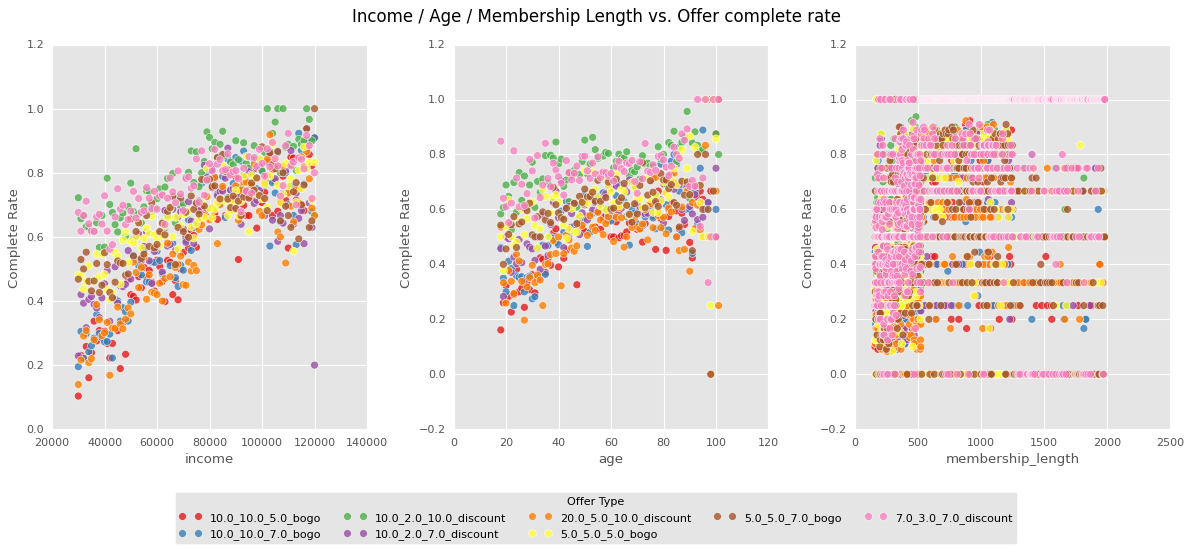

In [564]:
# scatter plot - income/age/membership_length vs. complete rate by offer type
plt.style.use('ggplot')
fig, axes = plt.subplots(1, 3, figsize = (15,6))
for ax, var in zip(axes, ['income','age','membership_length']):
    plot_data = scatter_df[
    ['offer_type_category', var,
        'offer_received', 'offer_viewed', 'offer_completed']
    ].groupby(
        ['offer_type_category', var],
        observed=True
        ).agg(
    receives=('offer_received', 'sum'),
    views=('offer_viewed', 'sum'),
    completes=('offer_completed', 'sum')
    ).reset_index()
    plot_data['view_rate'] = plot_data['views']/ plot_data['receives']
    plot_data['complete_rate'] = plot_data['completes']/ plot_data['receives']
    sns.scatterplot(
        data = plot_data,
        x = var,
        y = 'complete_rate',
        hue='offer_type_category',
        palette = 'Set1',
        s=50,
        alpha=0.8,
        ax=ax
    )
    ax.set_xlabel(var)
    ax.set_ylabel('Complete Rate')

plt.suptitle('Income / Age / Membership Length vs. Offer complete rate', fontsize=15)
# Get legend from first subplot
handles, labels = axes[0].get_legend_handles_labels()

# Remove individual subplot legends
for ax in axes:
    ax.get_legend().remove()

# Add one legend outside the figure
fig.legend(
    handles,
    labels,
    title='Offer Type',
    loc='lower center',
    bbox_to_anchor=(0.5, -0.15),
    ncol=5
)
plt.tight_layout()
plt.savefig('images/eda/scatter_completeRate.png')
plt.show()

## Clustering

### Create dataframes by offer features

Customer responding to offer types

In [216]:
# cluster data on offer types
cluster_df1 = df_merged.loc[
  (df_merged['offer_type'].isna()==False) & (df_merged['offer_type']!='informational'),
  ['customer_id','offer_type', 'difficulty','reward', 'duration', 'income_group','age_group','membership_length_group','offer_viewed',
   'offer_completed','offer_received']]

cluster_df1_group = cluster_df1.groupby(
  by = ['customer_id','offer_type','income_group','age_group', 'membership_length_group'],
  observed=True
).agg(
  receives = ('offer_received','sum'),
  views = ('offer_viewed','sum'),
  completes = ('offer_completed','sum')
  ).reset_index()

cluster_df1_group['view_rate'] = cluster_df1_group['views']/cluster_df1_group['receives']
cluster_df1_group['complete_rate'] = cluster_df1_group['completes']/cluster_df1_group['receives']


In [217]:
cluster_df1_group_pivot = cluster_df1_group.pivot(
  index=['customer_id', 'income_group','age_group','membership_length_group'],
  columns = 'offer_type',
  values = ['view_rate',
            'complete_rate']
).reset_index()

In [218]:
# flatten 2-level columns
cluster_df1_group_pivot.columns = cluster_df1_group_pivot.columns.map('_'.join)

cluster_offer_type = cluster_df1_group_pivot.rename(
  columns = {
   'income_group_':'income_group',
   'age_group_': 'age_group',
   'membership_length_group_':'membership_length_group',
   'customer_id_':'customer_id'
  }
)

Customer responding to offer diffiiculty, reward and duration

In [88]:
# cluster data on difficulty, reward, duration separately
cluster_df2 = df_merged.loc[
  (df_merged['offer_type'].isna()==False) & (df_merged['offer_type']!='informational'),
  ['customer_id','income_group','age_group','membership_length_group','offer_viewed','difficulty','reward','duration','offer_completed','offer_received']]

In [89]:
# create three dataframes
group_dfs = {}
for group in ['duration','difficulty','reward']:
  cluster_df2_group = cluster_df2.groupby(
    by = ['customer_id', group,'income_group','age_group', 'membership_length_group'],
    observed=True
  ).agg(
    receives = ('offer_received','sum'),
    views = ('offer_viewed','sum'),
    completes = ('offer_completed','sum')
    ).reset_index()

  cluster_df2_group['view_rate'] = cluster_df2_group['views']/cluster_df2_group['receives']
  cluster_df2_group['complete_rate'] = cluster_df2_group['completes']/cluster_df2_group['receives']
  group_dfs[group] = cluster_df2_group

In [90]:
# difficulaty
cluster_difficulty_pivot = group_dfs['difficulty'].pivot(
  index=['customer_id', 'income_group','age_group','membership_length_group'],
  columns = 'difficulty',
  values = ['view_rate',
            'complete_rate']
).reset_index()

cluster_difficulty_pivot.columns = [
    '_'.join([str(x) for x in col if x != ''])
    if isinstance(col, tuple)
    else str(col)
    for col in cluster_difficulty_pivot.columns
]
cluster_difficulty = cluster_difficulty_pivot

In [96]:
# reward
cluster_reward_pivot = group_dfs['reward'].pivot(
  index=['customer_id', 'income_group','age_group','membership_length_group'],
  columns = 'reward',
  values = ['view_rate',
            'complete_rate']
).reset_index()

cluster_reward_pivot.columns = [
    '_'.join([str(x) for x in col if x != ''])
    if isinstance(col, tuple)
    else str(col)
    for col in cluster_reward_pivot.columns
]
cluster_reward = cluster_reward_pivot

In [98]:
# duration
cluster_duration_pivot = group_dfs['duration'].pivot(
  index=['customer_id', 'income_group','age_group','membership_length_group'],
  columns = 'duration',
  values = ['view_rate',
            'complete_rate']
).reset_index()

cluster_duration_pivot.columns = [
    '_'.join([str(x) for x in col if x != ''])
    if isinstance(col, tuple)
    else str(col)
    for col in cluster_duration_pivot.columns
]
cluster_duration = cluster_duration_pivot

Customer responding to distribution channels

In [138]:
# cluster data on distibution channels
cluster_df3 = df_merged.loc[
  (df_merged['offer_type'].isna()==False) & (df_merged['offer_type']!='informational'),
  ['customer_id','income_group','age_group','membership_length_group','offer_viewed','mobile','web','social','email',
   'offer_completed','offer_received']]
# melt channels into one dimensional columns
cluster_df3_group = pd.DataFrame()
for p in ['mobile','web','social','email']:
  p_df = cluster_df3.loc[cluster_df3[p]==1]
  p_df['platform'] = p
  cluster_df3_group = pd.concat([cluster_df3_group, p_df])
cluster_df3_group.drop(columns= ['mobile','web','email','social'], inplace=True)

/var/folders/cr/df6gvtx90rz5bg2m0clb1gym0000gn/T/ipykernel_70891/2812775962.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  p_df['platform'] = p
/var/folders/cr/df6gvtx90rz5bg2m0clb1gym0000gn/T/ipykernel_70891/2812775962.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  p_df['platform'] = p
/var/folders/cr/df6gvtx90rz5bg2m0clb1gym0000gn/T/ipykernel_70891/2812775962.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexe

In [139]:
# group by
cluster_df3_group = cluster_df3_group.groupby(
  by = ['customer_id','platform','income_group','age_group', 'membership_length_group'],
  observed=True
).agg(
  receives = ('offer_received','sum'),
  views = ('offer_viewed','sum'),
  completes = ('offer_completed','sum')
  ).reset_index()
cluster_df3_group['view_rate'] = cluster_df3_group['views']/cluster_df3_group['receives']
cluster_df3_group['complete_rate'] = cluster_df3_group['completes']/cluster_df3_group['receives']

cluster_df3_group_pivot = cluster_df3_group.pivot(
  index = ['customer_id','income_group','age_group','membership_length_group'],
  columns = 'platform',
  values = ['view_rate','complete_rate']
).reset_index()

In [140]:
# flatten columns and rename
cluster_df3_group_pivot.columns = cluster_df3_group_pivot.columns.map('_'.join)
cluster_platform = cluster_df3_group_pivot.rename(
  columns = {
   'income_group_':'income_group',
   'age_group_': 'age_group',
   'membership_length_group_':'memnbership_length_group',
   'customer_id':'customer_id_'
  }
)

In [142]:
cluster_platform

,customer_id_,income_group,age_group,memnbership_length_group,view_rate_email,view_rate_mobile,view_rate_social,view_rate_web,complete_rate_email,complete_rate_mobile,complete_rate_social,complete_rate_web
0,0009655768c64bdeb2e877511632db8f,50k-80k,25-35,1-2 yr,0.666667,0.666667,1.0,0.666667,1.00,1.00,1.00,1.00
1,0011e0d4e6b944f998e987f904e8c1e5,50k-80k,35-45,0.5-1 yr,1.000000,1.000000,1.0,1.000000,1.00,1.00,1.00,1.00
2,0020c2b971eb4e9188eac86d93036a77,80-100k,55-65,2-5 yr,0.500000,0.500000,0.5,0.666667,0.75,0.75,0.75,1.00
3,0020ccbbb6d84e358d3414a3ff76cffd,50k-80k,<25,2-5 yr,1.000000,1.000000,1.0,1.000000,1.00,1.00,1.00,1.00
4,003d66b6608740288d6cc97a6903f4f0,50k-80k,25-35,1-2 yr,0.666667,1.000000,1.0,0.666667,1.00,1.00,1.00,1.00
...,...,...,...,...,...,...,...,...,...,...,...,...
14759,fff3ba4757bd42088c044ca26d73817a,80-100k,65+,2-5 yr,0.500000,0.500000,1.0,0.500000,0.75,0.75,1.00,0.75
14760,fff7576017104bcc8677a8d63322b5e1,50k-80k,65+,1-2 yr,0.800000,0.800000,1.0,0.750000,0.60,0.60,0.50,0.75
14761,fff8957ea8b240a6b5e634b6ee8eafcf,50k-80k,65+,0.5-1 yr,1.000000,1.000000,1.0,1.000000,0.00,0.00,0.00,0.00
14762,fffad4f4828548d1b5583907f2e9906b,<50k,25-35,1-2 yr,1.000000,1.000000,1.0,1.000000,1.00,1.00,1.00,1.00


### Clustrering - offer types


/var/folders/cr/df6gvtx90rz5bg2m0clb1gym0000gn/T/ipykernel_70891/3679707409.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  km_data_offer_type.dropna(axis=0, how='any', inplace=True)


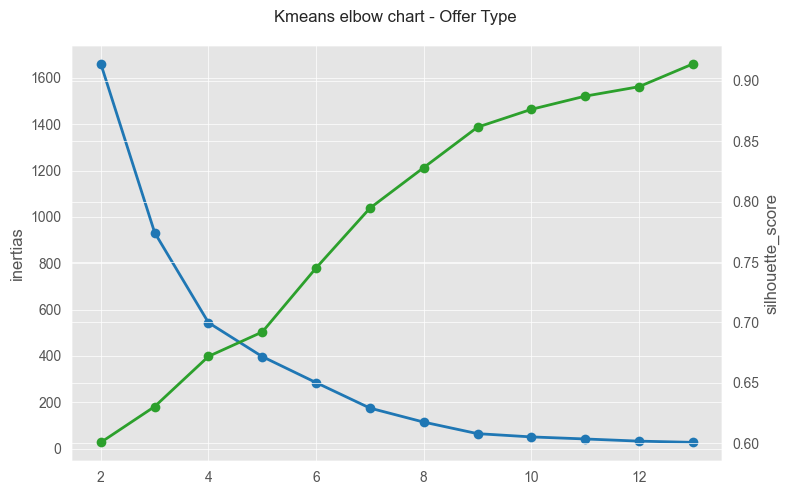

In [246]:
# kmeans clustering
#km_data_offer_type = cluster_offer_type.drop(columns = ['income_group','age_group','membership_length_group','customer_id'])
km_data_offer_type = cluster_offer_type[['complete_rate_bogo','complete_rate_discount']]
km_data_offer_type.dropna(axis=0, how='any', inplace=True)
inertias = []
silhouette = []

plt.style.use('ggplot')
for k in range(2, 14):
  kmeans = KMeans(
    n_clusters=k,
    random_state=42,
    n_init=10
  )
  kmeans.fit(km_data_offer_type)
  inertias.append(kmeans.inertia_)

  labels = kmeans.fit_predict(km_data_offer_type)
  silhouette.append(
    silhouette_score(km_data_offer_type, labels)
)

# plot
fig, ax1 = plt.subplots(figsize = (8, 5))
ax1.plot(
  range(2,14),
  inertias,
  marker = 'o',
  color='tab:blue'
)
ax1.set_ylabel('inertias')
ax2 = ax1.twinx()
ax2.plot(
  range(2,14),
  silhouette,
  marker = 'o',
  color = 'tab:green'
)
ax2.set_ylabel('silhouette_score')
plt.xlabel('number of clusters')
plt.suptitle('Kmeans elbow chart - Offer Type')
plt.tight_layout()
plt.savefig('images/clustering/kmeans_cluster_offer_type.png')

In [225]:
# set k=4 and find clusters
kmeans_4 = KMeans(
  n_clusters = 4,
  random_state=42,
  n_init=10
)
km_data_offer_type ['cluster_offer_type'] = kmeans_4.fit_predict(km_data_offer_type )


/var/folders/cr/df6gvtx90rz5bg2m0clb1gym0000gn/T/ipykernel_70891/273591080.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  km_data_offer_type ['cluster_offer_type'] = kmeans_4.fit_predict(km_data_offer_type )


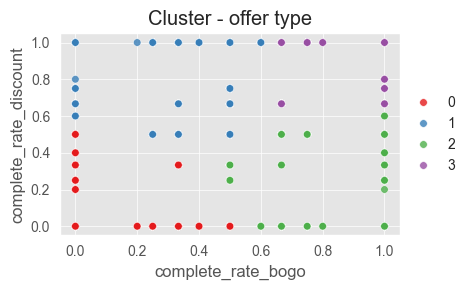

In [243]:
plt.figure(figsize=(5,3))
cluster_plot_offer_type = sns.scatterplot(
  data=km_data_offer_type,
  x='complete_rate_bogo',
  y='complete_rate_discount',
  hue='cluster_offer_type',
  palette='Set1',
  s=30,
  alpha=0.8
)
cluster_plot_offer_type.set_title('Cluster - offer type')
cluster_plot_offer_type.legend(
  loc='center right',
  bbox_to_anchor=(1.2, 0.5)
  )
plt.tight_layout()
plt.savefig('images/clustering/cluster_offer_type.png')
plt.show()


The cluster by offer type result shows that Cluster0 have medium-low complete rate on both offers; Cluster1 have high comnplete rate on Discount; Cluster2 have high complete rate on Bogo; Cluster3 have high complete rate on both

### Clustering - Difficulty

In [244]:
cluster_difficulty

,customer_id,income_group,age_group,membership_length_group,view_rate_5.0,view_rate_7.0,view_rate_10.0,view_rate_20.0,complete_rate_5.0,complete_rate_7.0,complete_rate_10.0,complete_rate_20.0
0,0009655768c64bdeb2e877511632db8f,50k-80k,25-35,1-2 yr,1.0,NaN,0.500000,NaN,1.0,NaN,1.000000,NaN
1,0011e0d4e6b944f998e987f904e8c1e5,50k-80k,35-45,0.5-1 yr,1.0,1.0,NaN,1.0,1.0,1.0,NaN,1.0
2,0020c2b971eb4e9188eac86d93036a77,80-100k,55-65,2-5 yr,NaN,NaN,0.500000,NaN,NaN,NaN,0.750000,NaN
3,0020ccbbb6d84e358d3414a3ff76cffd,50k-80k,<25,2-5 yr,1.0,1.0,NaN,NaN,1.0,1.0,NaN,NaN
4,003d66b6608740288d6cc97a6903f4f0,50k-80k,25-35,1-2 yr,NaN,NaN,1.000000,0.0,NaN,NaN,1.000000,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...
14759,fff3ba4757bd42088c044ca26d73817a,80-100k,65+,2-5 yr,1.0,NaN,0.333333,NaN,1.0,NaN,0.666667,NaN
14760,fff7576017104bcc8677a8d63322b5e1,50k-80k,65+,1-2 yr,0.0,NaN,1.000000,NaN,1.0,NaN,0.500000,NaN
14761,fff8957ea8b240a6b5e634b6ee8eafcf,50k-80k,65+,0.5-1 yr,NaN,NaN,1.000000,NaN,NaN,NaN,0.000000,NaN
14762,fffad4f4828548d1b5583907f2e9906b,<50k,25-35,1-2 yr,1.0,NaN,NaN,NaN,1.0,NaN,NaN,NaN


/var/folders/cr/df6gvtx90rz5bg2m0clb1gym0000gn/T/ipykernel_70891/3682246168.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  km_data_difficulty.dropna(axis=0, how='any', inplace=True)


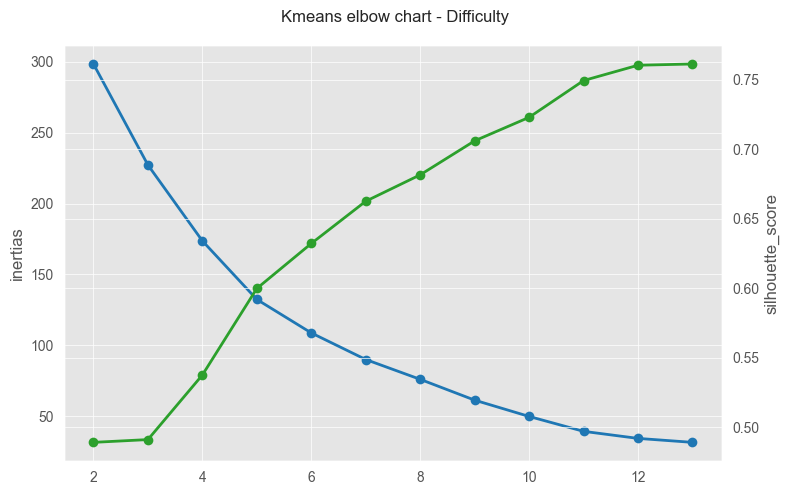

In [247]:
# kmeans clustering
km_data_difficulty = cluster_difficulty[['complete_rate_5.0','complete_rate_7.0','complete_rate_10.0','complete_rate_20.0']]
km_data_difficulty.dropna(axis=0, how='any', inplace=True)
inertias = []
silhouette = []

plt.style.use('ggplot')
for k in range(2, 14):
  kmeans = KMeans(
    n_clusters=k,
    random_state=42,
    n_init=10
  )
  kmeans.fit(km_data_difficulty)
  inertias.append(kmeans.inertia_)

  labels = kmeans.fit_predict(km_data_difficulty)
  silhouette.append(
    silhouette_score(km_data_difficulty, labels)
)

# plot
fig, ax1 = plt.subplots(figsize = (8, 5))
ax1.plot(
  range(2,14),
  inertias,
  marker = 'o',
  color='tab:blue'
)
ax1.set_ylabel('inertias')
ax2 = ax1.twinx()
ax2.plot(
  range(2,14),
  silhouette,
  marker = 'o',
  color = 'tab:green'
)
ax2.set_ylabel('silhouette_score')
plt.xlabel('number of clusters')
plt.suptitle('Kmeans elbow chart - Difficulty')
plt.tight_layout()
plt.savefig('images/clustering/kmeans_cluster_difficulty.png')


In [250]:
# set k=5 and find clusters
kmeans_5 = KMeans(
  n_clusters = 5,
  random_state=42,
  n_init=10
)
km_data_difficulty['cluster_difficulty'] = kmeans_5.fit_predict(km_data_difficulty)

/var/folders/cr/df6gvtx90rz5bg2m0clb1gym0000gn/T/ipykernel_70891/3084503311.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  km_data_difficulty['cluster_difficulty'] = kmeans_5.fit_predict(km_data_difficulty)


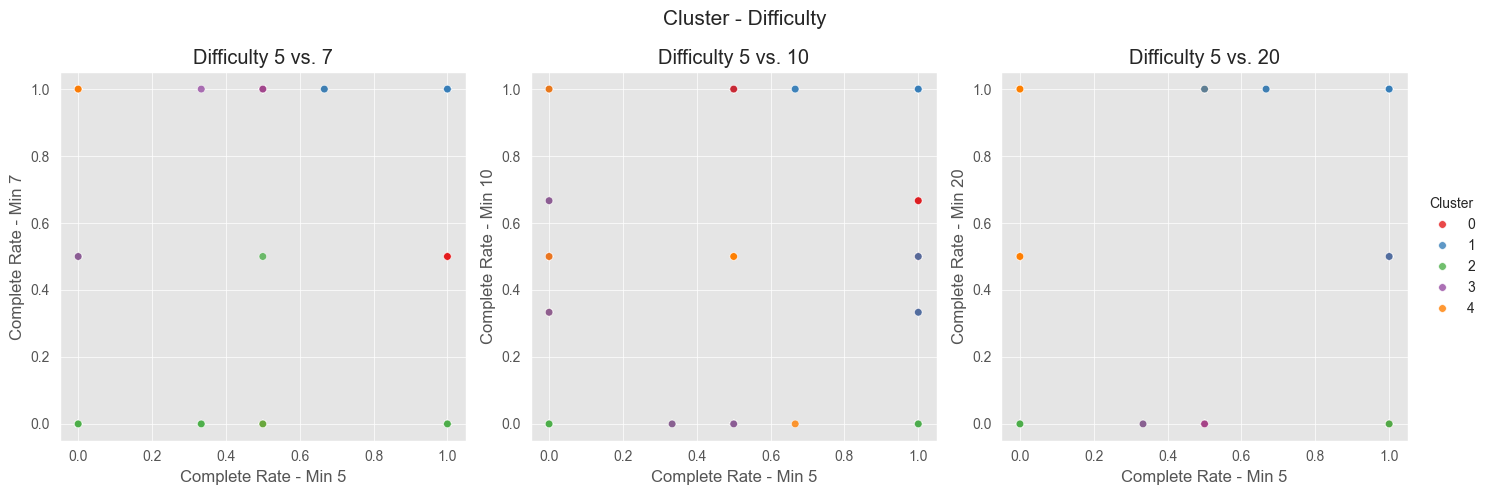

In [270]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Plot 1
sns.scatterplot(
    data=km_data_difficulty,
    x='complete_rate_5.0',
    y='complete_rate_7.0',
    hue='cluster_difficulty',
    palette='Set1',
    s=30,
    alpha=0.8,
    ax=axes[0]
)
axes[0].set_title('Difficulty 5 vs. 7')
axes[0].set_xlabel('Complete Rate - Min 5')
axes[0].set_ylabel('Complete Rate - Min 7')
axes[0].legend_.remove()

# Plot 2
sns.scatterplot(
    data=km_data_difficulty,
    x='complete_rate_5.0',
    y='complete_rate_10.0',
    hue='cluster_difficulty',
    palette='Set1',
    s=30,
    alpha=0.8,
    ax=axes[1]
)
axes[1].set_title('Difficulty 5 vs. 10')
axes[1].set_xlabel('Complete Rate - Min 5')
axes[1].set_ylabel('Complete Rate - Min 10')
axes[1].legend_.remove()

# Plot 3
sns.scatterplot(
    data=km_data_difficulty,
    x='complete_rate_5.0',
    y='complete_rate_20.0',
    hue='cluster_difficulty',
    palette='Set1',
    s=30,
    alpha=0.8,
    ax=axes[2]
)
axes[2].set_title('Difficulty 5 vs. 20')
axes[2].set_xlabel('Complete Rate - Min 5')
axes[2].set_ylabel('Complete Rate - Min 20')


# Keep only one legend
axes[2].legend(
    title='Cluster',
    loc='center left',
    bbox_to_anchor=(1.02, 0.5)
)
plt.suptitle('Cluster - Difficulty', fontsize=15)
plt.tight_layout()
plt.show()

In [261]:
km_data_difficulty

,complete_rate_5.0,complete_rate_7.0,complete_rate_10.0,complete_rate_20.0,cluster_difficulty
27,1.0,1.0,1.0,1.0,1
33,0.0,0.0,0.0,0.0,2
35,1.0,0.0,0.0,0.0,2
51,1.0,1.0,0.0,1.0,1
111,1.0,1.0,1.0,1.0,1
...,...,...,...,...,...
14549,0.0,1.0,0.5,1.0,4
14555,0.0,0.0,0.0,0.0,2
14591,0.0,0.0,0.0,0.0,2
14722,1.0,1.0,1.0,1.0,1


### Clustering - Platforms

In [262]:
cluster_platform

,customer_id_,income_group,age_group,memnbership_length_group,view_rate_email,view_rate_mobile,view_rate_social,view_rate_web,complete_rate_email,complete_rate_mobile,complete_rate_social,complete_rate_web
0,0009655768c64bdeb2e877511632db8f,50k-80k,25-35,1-2 yr,0.666667,0.666667,1.0,0.666667,1.00,1.00,1.00,1.00
1,0011e0d4e6b944f998e987f904e8c1e5,50k-80k,35-45,0.5-1 yr,1.000000,1.000000,1.0,1.000000,1.00,1.00,1.00,1.00
2,0020c2b971eb4e9188eac86d93036a77,80-100k,55-65,2-5 yr,0.500000,0.500000,0.5,0.666667,0.75,0.75,0.75,1.00
3,0020ccbbb6d84e358d3414a3ff76cffd,50k-80k,<25,2-5 yr,1.000000,1.000000,1.0,1.000000,1.00,1.00,1.00,1.00
4,003d66b6608740288d6cc97a6903f4f0,50k-80k,25-35,1-2 yr,0.666667,1.000000,1.0,0.666667,1.00,1.00,1.00,1.00
...,...,...,...,...,...,...,...,...,...,...,...,...
14759,fff3ba4757bd42088c044ca26d73817a,80-100k,65+,2-5 yr,0.500000,0.500000,1.0,0.500000,0.75,0.75,1.00,0.75
14760,fff7576017104bcc8677a8d63322b5e1,50k-80k,65+,1-2 yr,0.800000,0.800000,1.0,0.750000,0.60,0.60,0.50,0.75
14761,fff8957ea8b240a6b5e634b6ee8eafcf,50k-80k,65+,0.5-1 yr,1.000000,1.000000,1.0,1.000000,0.00,0.00,0.00,0.00
14762,fffad4f4828548d1b5583907f2e9906b,<50k,25-35,1-2 yr,1.000000,1.000000,1.0,1.000000,1.00,1.00,1.00,1.00


/var/folders/cr/df6gvtx90rz5bg2m0clb1gym0000gn/T/ipykernel_70891/3817855947.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  km_data_platform.dropna(axis=0, how='any', inplace=True)


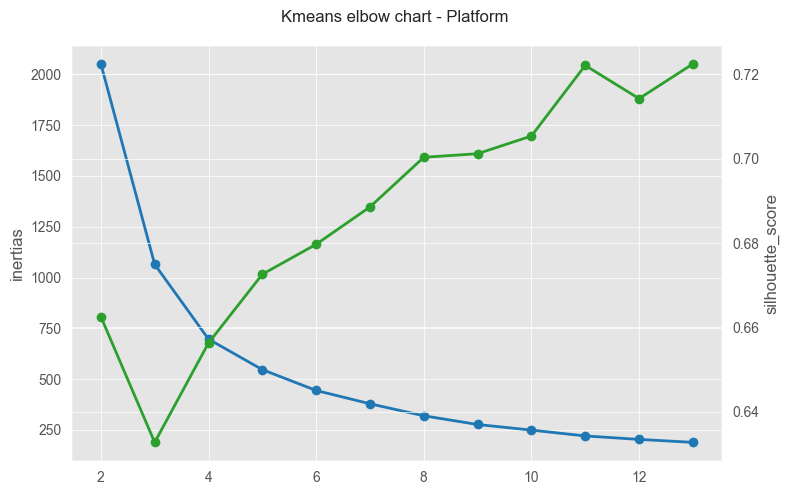

In [272]:
# kmeans clustering
km_data_platform = cluster_platform[['complete_rate_email','complete_rate_social','complete_rate_web','complete_rate_mobile']]
km_data_platform.dropna(axis=0, how='any', inplace=True)
inertias = []
silhouette = []

plt.style.use('ggplot')
for k in range(2, 14):
  kmeans = KMeans(
    n_clusters=k,
    random_state=42,
    n_init=10
  )
  kmeans.fit(km_data_platform)
  inertias.append(kmeans.inertia_)

  labels = kmeans.fit_predict(km_data_platform)
  silhouette.append(
    silhouette_score(km_data_platform, labels)
)

# plot
fig, ax1 = plt.subplots(figsize = (8, 5))
ax1.plot(
  range(2,14),
  inertias,
  marker = 'o',
  color='tab:blue'
)
ax1.set_ylabel('inertias')
ax2 = ax1.twinx()
ax2.plot(
  range(2,14),
  silhouette,
  marker = 'o',
  color = 'tab:green'
)
ax2.set_ylabel('silhouette_score')
plt.xlabel('number of clusters')
plt.suptitle('Kmeans elbow chart - Platform')
plt.tight_layout()
plt.savefig('images/clustering/kmeans_cluster_platform.png')


In [265]:
# set k=5 and find clusters
kmeans_5 = KMeans(
  n_clusters = 5,
  random_state=42,
  n_init=10
)
km_data_platform['cluster_platform'] = kmeans_5.fit_predict(km_data_platform)

/var/folders/cr/df6gvtx90rz5bg2m0clb1gym0000gn/T/ipykernel_70891/1331381.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  km_data_platform['cluster_platform'] = kmeans_5.fit_predict(km_data_platform)


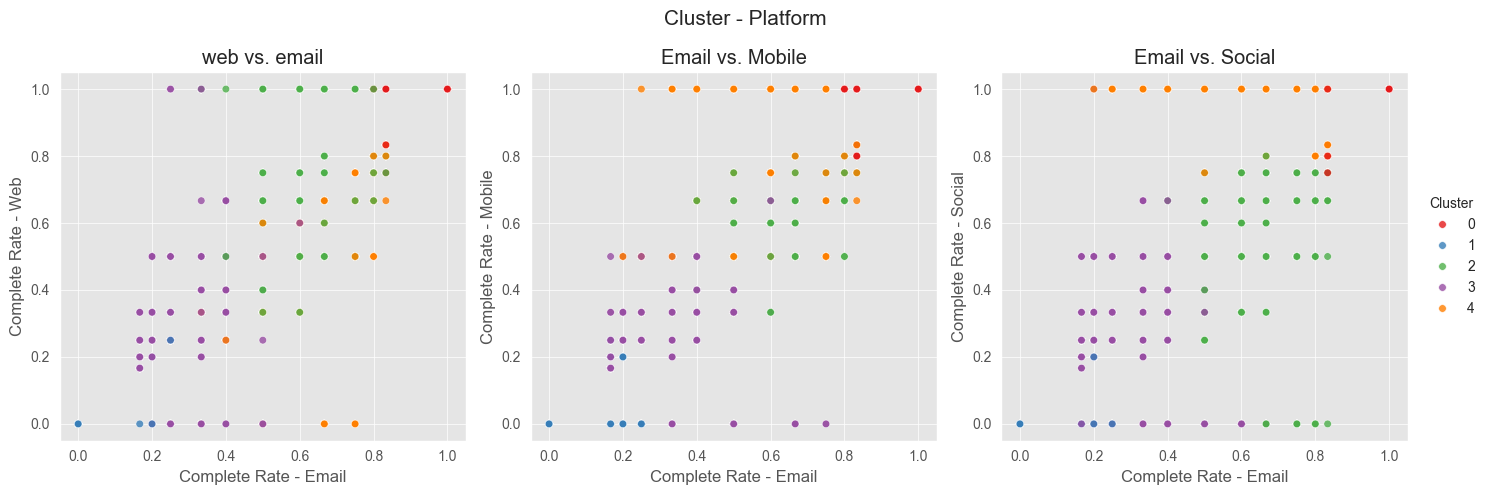

In [271]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Plot 1
sns.scatterplot(
    data=km_data_platform,
    x='complete_rate_email',
    y='complete_rate_web',
    hue='cluster_platform',
    palette='Set1',
    s=30,
    alpha=0.8,
    ax=axes[0]
)
axes[0].set_title('web vs. email')
axes[0].set_xlabel('Complete Rate - Email')
axes[0].set_ylabel('Complete Rate - Web')
axes[0].legend_.remove()

# Plot 2
sns.scatterplot(
    data=km_data_platform,
    x='complete_rate_email',
    y='complete_rate_mobile',
    hue='cluster_platform',
    palette='Set1',
    s=30,
    alpha=0.8,
    ax=axes[1]
)
axes[1].set_title('Email vs. Mobile')
axes[1].set_xlabel('Complete Rate - Email')
axes[1].set_ylabel('Complete Rate - Mobile')
axes[1].legend_.remove()

# Plot 3
sns.scatterplot(
    data=km_data_platform,
    x='complete_rate_email',
    y='complete_rate_social',
    hue='cluster_platform',
    palette='Set1',
    s=30,
    alpha=0.8,
    ax=axes[2]
)
axes[2].set_title('Email vs. Social')
axes[2].set_xlabel('Complete Rate - Email')
axes[2].set_ylabel('Complete Rate - Social')


# Keep only one legend
axes[2].legend(
    title='Cluster',
    loc='center left',
    bbox_to_anchor=(1.02, 0.5)
)
plt.suptitle('Cluster - Platform', fontsize=15)
plt.tight_layout()
plt.savefig('images/clustering/cluster_platform.png')
plt.show()


The cluster by plaform result shows that Cluster3 have relatively low complete rate through Mobile channel; Cluster2 have medium high complete rates on all channels; Cluster4 have high complete rate on both Mobile and Social channels

### Clustering - Duration

In [273]:
cluster_duration

,customer_id,income_group,age_group,membership_length_group,view_rate_5.0,view_rate_7.0,view_rate_10.0,complete_rate_5.0,complete_rate_7.0,complete_rate_10.0
0,0009655768c64bdeb2e877511632db8f,50k-80k,25-35,1-2 yr,1.0,0.000000,1.000000,1.0,1.000000,1.0
1,0011e0d4e6b944f998e987f904e8c1e5,50k-80k,35-45,0.5-1 yr,NaN,1.000000,1.000000,NaN,1.000000,1.0
2,0020c2b971eb4e9188eac86d93036a77,80-100k,55-65,2-5 yr,1.0,0.000000,0.500000,1.0,0.000000,1.0
3,0020ccbbb6d84e358d3414a3ff76cffd,50k-80k,<25,2-5 yr,1.0,1.000000,NaN,1.0,1.000000,NaN
4,003d66b6608740288d6cc97a6903f4f0,50k-80k,25-35,1-2 yr,NaN,NaN,0.666667,NaN,NaN,1.0
...,...,...,...,...,...,...,...,...,...,...
14759,fff3ba4757bd42088c044ca26d73817a,80-100k,65+,2-5 yr,NaN,0.333333,1.000000,NaN,0.666667,1.0
14760,fff7576017104bcc8677a8d63322b5e1,50k-80k,65+,1-2 yr,1.0,0.500000,1.000000,0.0,0.500000,1.0
14761,fff8957ea8b240a6b5e634b6ee8eafcf,50k-80k,65+,0.5-1 yr,1.0,NaN,1.000000,0.0,NaN,0.0
14762,fffad4f4828548d1b5583907f2e9906b,<50k,25-35,1-2 yr,1.0,1.000000,NaN,1.0,1.000000,NaN


/var/folders/cr/df6gvtx90rz5bg2m0clb1gym0000gn/T/ipykernel_70891/2673267331.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  km_data_duration.dropna(axis=0, how='any', inplace=True)


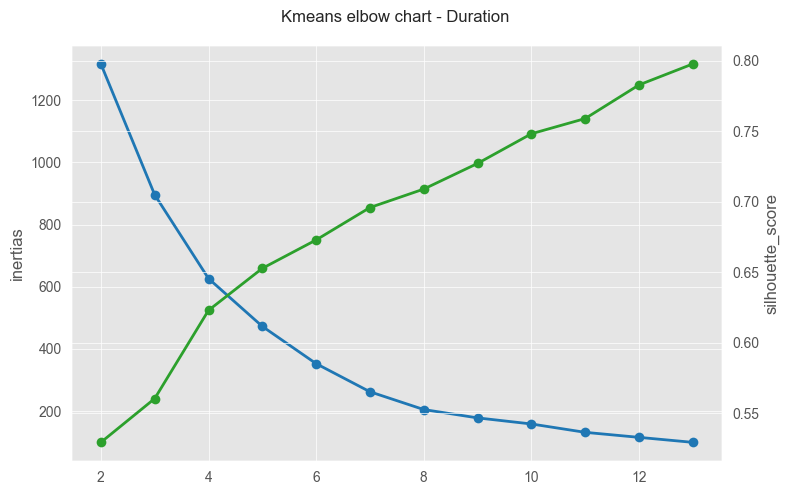

In [275]:
# kmeans clustering
km_data_duration = cluster_duration[['complete_rate_5.0','complete_rate_7.0','complete_rate_10.0']]
km_data_duration.dropna(axis=0, how='any', inplace=True)
inertias = []
silhouette = []

plt.style.use('ggplot')
for k in range(2, 14):
  kmeans = KMeans(
    n_clusters=k,
    random_state=42,
    n_init=10
  )
  kmeans.fit(km_data_duration)
  inertias.append(kmeans.inertia_)

  labels = kmeans.fit_predict(km_data_duration)
  silhouette.append(
    silhouette_score(km_data_duration, labels)
)

# plot
fig, ax1 = plt.subplots(figsize = (8, 5))
ax1.plot(
  range(2,14),
  inertias,
  marker = 'o',
  color='tab:blue'
)
ax1.set_ylabel('inertias')
ax2 = ax1.twinx()
ax2.plot(
  range(2,14),
  silhouette,
  marker = 'o',
  color = 'tab:green'
)
ax2.set_ylabel('silhouette_score')
plt.xlabel('number of clusters')
plt.suptitle('Kmeans elbow chart - Duration')
plt.tight_layout()
plt.savefig('images/clustering/kmeans_cluster_duration.png')


In [276]:
# set k=4 and find clusters
kmeans_4 = KMeans(
  n_clusters = 4,
  random_state=42,
  n_init=10
)
km_data_duration['cluster_duration'] = kmeans_4.fit_predict(km_data_duration)

/var/folders/cr/df6gvtx90rz5bg2m0clb1gym0000gn/T/ipykernel_70891/792674704.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  km_data_duration['cluster_duration'] = kmeans_4.fit_predict(km_data_duration)


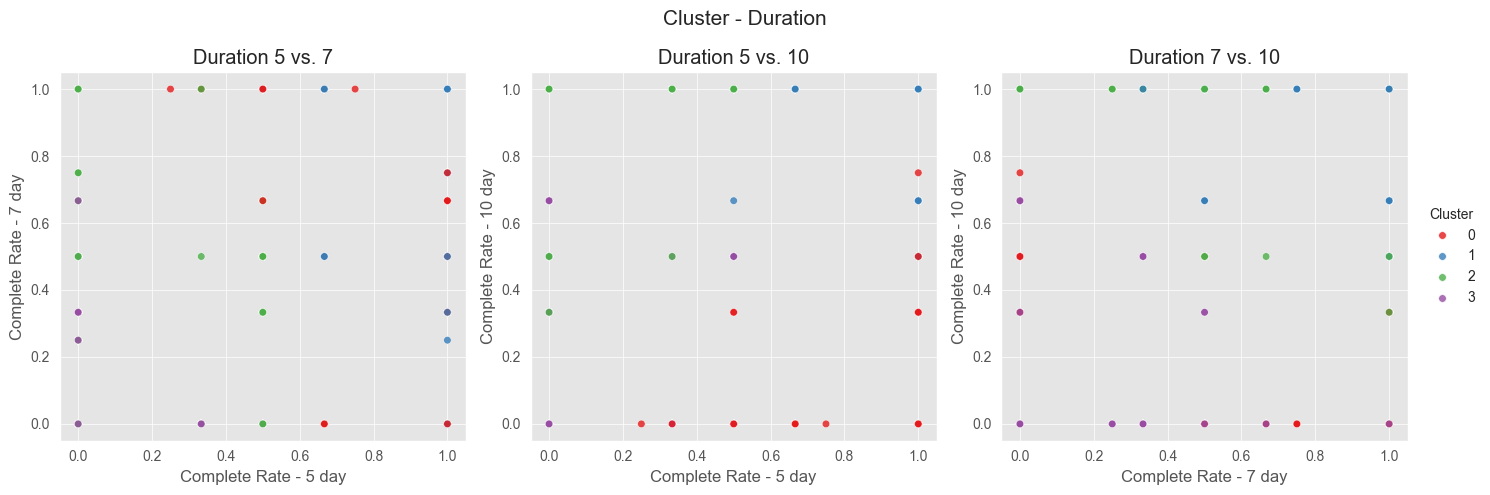

In [282]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Plot 1
sns.scatterplot(
    data=km_data_duration,
    x='complete_rate_5.0',
    y='complete_rate_7.0',
    hue='cluster_duration',
    palette='Set1',
    s=30,
    alpha=0.8,
    ax=axes[0]
)
axes[0].set_title('Duration 5 vs. 7')
axes[0].set_xlabel('Complete Rate - 5 day')
axes[0].set_ylabel('Complete Rate - 7 day')
axes[0].legend_.remove()

# Plot 2
sns.scatterplot(
    data=km_data_duration,
    x='complete_rate_5.0',
    y='complete_rate_10.0',
    hue='cluster_duration',
    palette='Set1',
    s=30,
    alpha=0.8,
    ax=axes[1]
)
axes[1].set_title('Duration 5 vs. 10')
axes[1].set_xlabel('Complete Rate - 5 day')
axes[1].set_ylabel('Complete Rate - 10 day')
axes[1].legend_.remove()

# Plot 3
sns.scatterplot(
    data=km_data_duration,
    x='complete_rate_7.0',
    y='complete_rate_10.0',
    hue='cluster_duration',
    palette='Set1',
    s=30,
    alpha=0.8,
    ax=axes[2]
)
axes[2].set_title('Duration 7 vs. 10')
axes[2].set_xlabel('Complete Rate - 7 day')
axes[2].set_ylabel('Complete Rate - 10 day')


# Keep only one legend
axes[2].legend(
    title='Cluster',
    loc='center left',
    bbox_to_anchor=(1.02, 0.5)
)
plt.suptitle('Cluster - Duration', fontsize=15)
plt.tight_layout()
plt.savefig('images/clustering/cluster_duration.png')
plt.show()


The clustering on offer duration indicates that Cluster1 and Cluster2 have consistently high complete rate for long durarion offers. 